# FDSI benchmark: calibration

`CBSS` (convolutive blind source separation) turns a short window of raw HD-EMG into a calibrated
motor-unit decomposition -- whitening + separation vectors, plus each unit's spike centroids for
later spike detection. This notebook calibrates one unit set per (subject, condition, SNR)
recording in the FDSI benchmark, over the first 5 s of each recording (assumed stationary), then
keeps only the units whose spikes reliably match the simulated ground truth
(`CBSSResult.select_supervised`). Shared by every branch (`sv_loss`/`pareto`/`roa`) -- calibration
doesn't depend on the optimisation objective, so this is the one common starting point all three
read from.

**Load-only by default** (`RUN_CALIBRATION=False`) -- reads the already-computed cache under
`FDSI_ROOT/calibration/`, does not recompute the benchmark.

## Config

In [1]:
RUN_CALIBRATION = False   # compute missing calibration/<sub>/..._cbss.pkl -- default False, cache-hit only

import yaml
from pathlib import Path

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

FDSI_ROOT = Path(grid['fdsi_root'])
DATA_DIR, CAL_DIR, ADAPT_DIR = FDSI_ROOT / 'data', FDSI_ROOT / 'calibration', FDSI_ROOT / 'adaptation'
OPT_DIR = ADAPT_DIR / 'optimisation'

FS, EXT_FACT = grid['fs'], grid['ext_fact']
TOL_SPIKE_MS, ROA_CAL_TH = grid['tol_spike_ms'], grid['roa_cal_th']
CAL_END, ISO_DUR = int(grid['cal_duration_s'] * FS), int(grid['iso_duration_s'] * FS)

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]

POOL_CONDITIONS = grid['pool_conditions']
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]
OPTIM_SUB, OPTIM_SNR, N_TRIALS = grid['optim_sub'], grid['optim_snr'], grid['n_trials']

BASE_CONFIG_DIR = Path('../../configs/adapt_configs')
BASE_CONFIG_PATH = BASE_CONFIG_DIR / 'default_muniverse.yaml'   # wh_sv_coupling=True; lr_mode overridden per branch below
LR_TOKEN_TO_MODE = {'lr_fixed': 'fixed', 'lr_relerror': 'rel_error'}

print(f'Apply-to-all grid: {len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} recordings')

Apply-to-all grid: 5 subjects x 5 conditions x 4 SNR levels = 100 recordings


## Calibrate one recording

Before scaling to the full grid below, run `CBSS` directly on a single recording so the
calibration call sequence is visible in one place: `CBSS(cbss_config).decompose(emg, ts)` gives
every source/spike train CBSS finds, and `CBSSResult.select_supervised` then keeps only the units
whose spikes match a ground-truth unit above `ROA_CAL_TH`. This is
`OPTIM_SUB`/`TRIANGULAR[0]`/`OPTIM_SNR` -- the same recording every `03*_optimisation.ipynb`
branch's pooled hyperparameter search uses.

In [2]:
import sys
sys.path.insert(0, '../..')          # package root
sys.path.insert(0, str(Path.cwd()))  # this notebook's own directory, for fdsi_common

import numpy as np

from adapt_decomp import CBSS, CBSSConfig
from adapt_decomp.utils import load_gt
import fdsi_common as fc

sub, cond, snr = OPTIM_SUB, TRIANGULAR[0], OPTIM_SNR

# Load data
emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
emg_calib, ts_calib = emg_full[:CAL_END], np.arange(CAL_END) / FS
gt_bin = load_gt(fc.gt_spikes_path(DATA_DIR, sub, cond), n_samples=CAL_END)

# Calibrate
cbss_config = CBSSConfig(
    fs=FS,
    ext_fact=EXT_FACT,
    sil_th=0.9,
    random_seed=42,
    ica_iter=300,
    search_iter=300,
    save_emg=True
)
cbss_result = CBSS(cbss_config).decompose(emg_calib, ts_calib)

# Match to ground truth and keep only reliable units
cbss_result = cbss_result.select_supervised(gt_bin, roa_th=ROA_CAL_TH, tol_spike_ms=TOL_SPIKE_MS, fs=FS)
print(f'{sub} {cond} snr{snr}dB: {cbss_result.spikes_centr.shape[0]} units kept '
      f'(RoA > {int(ROA_CAL_TH*100)} % vs GT).')

sub-01 triangular-ramp40s snr30dB: 14 units kept (RoA > 90 % vs GT).


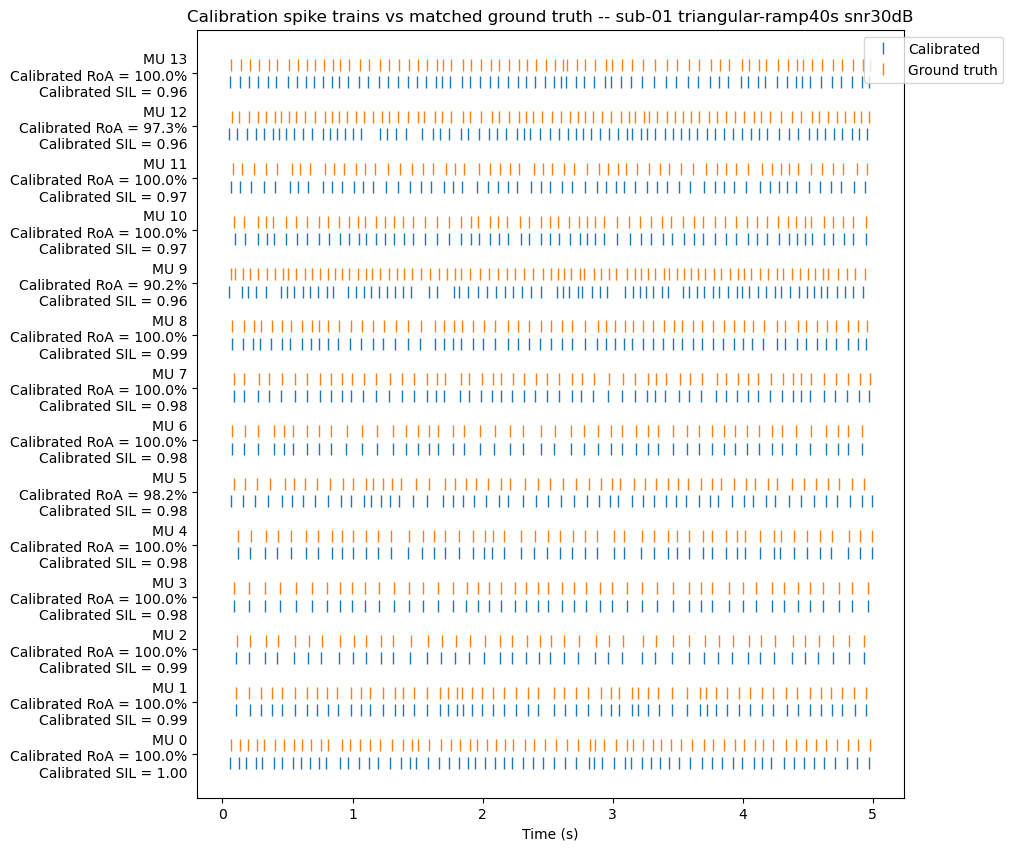

In [3]:
import matplotlib.pyplot as plt

from adapt_decomp.utils.plots import plot_spikes

ax = plot_spikes(
    {'Calibrated': cbss_result.spikes, 'Ground truth': gt_bin[:, cbss_result.gt_matched_indices]},
    ts_calib,
    roa={'Calibrated': cbss_result.roa},
    sil={'Calibrated': cbss_result.sil},
)
ax.set_title(f'Calibration spike trains vs matched ground truth -- {sub} {cond} snr{snr}dB')
plt.show()

## Calibrate the full benchmark grid

`run_calibration` below is exactly the call sequence just shown, wrapped for reuse and disk
caching: results are saved to `FDSI_ROOT/calibration/<sub>/` on first run and loaded straight back
on every later one, so re-running this cell (or any downstream notebook that also derives
`calibrations`) is cheap by default (`RUN_CALIBRATION=False`).

In [4]:
from typing import Dict, Optional, Tuple
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp import CBSSResult


def run_calibration(sub: str, cond: str, snr: int) -> Optional[CBSSResult]:
    """Load this recording's cached calibration, or compute it if RUN_CALIBRATION is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.

    Returns:
        Optional[CBSSResult]: The calibration, or None if uncached and not computed, or if
            no unit matched the ground truth above ROA_CAL_TH.
    """
    result_path, config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    if result_path.exists():
        return CBSSResult.load(result_path)
    if not RUN_CALIBRATION:
        return None

    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    emg_calib, ts_calib = emg_full[:CAL_END], np.arange(CAL_END) / FS
    gt_bin = load_gt(fc.gt_spikes_path(DATA_DIR, sub, cond), n_samples=CAL_END)

    cbss_config = CBSSConfig(fs=FS, ext_fact=EXT_FACT, sil_th=0.9, random_seed=42,
                              ica_iter=300, search_iter=300, save_emg=True)
    try:
        result = CBSS(cbss_config).decompose(emg_calib, ts_calib)
        result = result.select_supervised(gt_bin, roa_th=ROA_CAL_TH, tol_spike_ms=TOL_SPIKE_MS, fs=FS)
    except ValueError as exc:
        print(f'  [calibration skipped] {sub} {cond} snr{snr}dB: {exc}')
        return None

    result_path.parent.mkdir(parents=True, exist_ok=True)
    result.save(result_path)
    cbss_config.to_yaml(config_path)
    return result


calibrations: Dict[Tuple[str, str, int], Optional[CBSSResult]] = {}
pbar = tqdm(total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS), desc='Calibration')
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            calibrations[(sub, cond, snr)] = run_calibration(sub, cond, snr)
            pbar.update(1)
pbar.close()

n_cal = sum(v is not None for v in calibrations.values())
print(f'Calibration available: {n_cal}/{len(calibrations)} recordings.')

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Calibration available: 100/100 recordings.


`calibrations` is this notebook's own in-memory result -- every downstream notebook (`02_fixed_adaptation.ipynb` onward) re-derives the same dict from the same on-disk cache rather than depending on this notebook's Python state; the cache *is* the handoff.

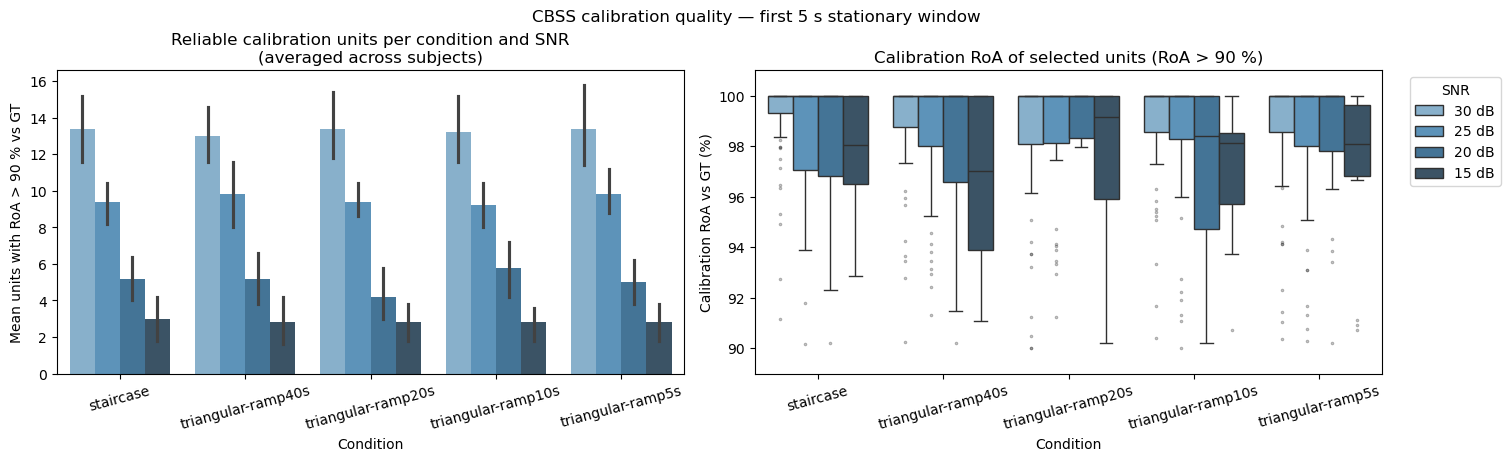

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build calibration summary dataframes
summary_rows, cal_rows = [], []
for (sub, cond, snr), cal in calibrations.items():
    if cal is None:
        continue
    n_kept = 0 if cal.roa is None else len(cal.roa)
    summary_rows.append({'sub': sub, 'condition': cond, 'snr': snr, 'n_kept': n_kept})
    for roa_val in cal.roa:
        cal_rows.append({
            'sub':       sub,
            'condition': cond,
            'snr':       snr,
            'roa_cal':   float(roa_val) * 100,
        })

df_summary = pd.DataFrame(summary_rows)
df_cal = pd.DataFrame(cal_rows)

snr_order = [f'{s} dB' for s in SNR_LEVELS]
df_summary['SNR'] = df_summary['snr'].astype(str) + ' dB'
df_cal['SNR'] = df_cal['snr'].astype(str) + ' dB'

# Plot resutls
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5), layout='constrained')

# Left: mean number of reliably detected units per condition × SNR
sns.barplot(
    data=df_summary, x='condition', y='n_kept', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d', ax=axs[0], legend=False
)
axs[0].set(
    ylabel=f'Mean units with RoA > {int(ROA_CAL_TH*100)} % vs GT',
    xlabel='Condition',
    title='Reliable calibration units per condition and SNR\n(averaged across subjects)',
)
axs[0].tick_params(axis='x', rotation=15)

# Right: distribution of calibration RoA for selected units
sns.boxplot(
    data=df_cal, x='condition', y='roa_cal', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d',
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=axs[1],
)
axs[1].set(
    ylabel='Calibration RoA vs GT (%)',
    xlabel='Condition',
    title=f'Calibration RoA of selected units (RoA > {int(ROA_CAL_TH*100)} %)',
    ylim=(ROA_CAL_TH * 100 - 1, 101),
)
axs[1].tick_params(axis='x', rotation=15)
axs[1].legend(title='SNR', loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.suptitle('CBSS calibration quality — first 5 s stationary window')
plt.show()
